In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.01 # In [fm^-2]
ENDING_RANGE_PARAMETER = 250
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 50 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

NUM_SUSY_GAUSSIANS = 15
SUSY_POTENTIAL_PARAMS = [0.015625,0.0216263,0.0299326,0.0414292,0.0573414,0.0793653,0.109848,
                                   0.152039,0.210435,0.291259,0.403127,0.557961,0.772264,1.06888,1.47942]
SUSY_POTENTIAL_COEFFS = np.array([-33.7795,125.728,-214.962,195.943,-59.5447,-118.117,235.946,-253.234,305.881,-243.858,148.467,
                         -74.1628,29.1132,-7.90282,1.0961])
CENTRAL_POTENTIAL_STRENGTH = -47.32 * 2

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30 * 1)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [17]:
def single_particle_overlap(range_parameter_i, range_parameter_j, orbital_angular_momentum):
    term_1 = 2 * range_parameter_i * range_parameter_j
    term_2 = range_parameter_i**2 + range_parameter_j**2
    return (term_1 / term_2)**((5/2) + orbital_angular_momentum)

def single_particle_potential_element(range_parameter_i, range_parameter_j, orbital_angular_momentum,
                                      mixing_coefficient, potential_strength, potential_param):
    """
    term_1 = 2 * range_parameter_i * range_parameter_j
    term_2 = range_parameter_i**2 + range_parameter_j**2 
    term_3 = range_parameter_i**2 * range_parameter_j**2 * potential_param
    return mixing_coefficient * potential_strength * (term_1 / (term_2 + term_3))**((5/2) + orbital_angular_momentum)
    """
    term_1 = (2 / (range_parameter_i * range_parameter_j))**(2.5 + orbital_angular_momentum)
    term_2 = (range_parameter_i**(-2) + range_parameter_j**(-2) + potential_param)**(2.5 + orbital_angular_momentum)
    return mixing_coefficient * potential_strength * term_1 / term_2

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, orbital_angular_momentum, μ=REDUCED_MASS):
    term_A = (2**((7/2) + orbital_angular_momentum)) / (3 + 2 * orbital_angular_momentum)

    term_1 = ((orbital_angular_momentum + 0) * (orbital_angular_momentum + 1)) / (range_parameter_i * range_parameter_j)
    term_2 = ((range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5 + orbital_angular_momentum)
    term_B = term_1 * term_2

    term_3 = (range_parameter_i * range_parameter_j)**(0.5 + orbital_angular_momentum)
    term_4 = (range_parameter_i**2 + range_parameter_j**2)**((7/2) + orbital_angular_momentum)
    term_5 = (orbital_angular_momentum + 1) * (orbital_angular_momentum + 2) * (range_parameter_i**4 + range_parameter_j**4)
    term_6 = (11 + 2 * orbital_angular_momentum * (5 + orbital_angular_momentum)) * range_parameter_i**2 * range_parameter_j**2
    term_C = (term_3 / term_4) * (term_5 - term_6)

    return (197**2 / (2 * μ)) * (term_A * (term_B - term_C))

def r_minus_two_element(range_parameter_i, range_parameter_j, orbital_angular_momentum, μ=REDUCED_MASS):
    term_1 = (2**((9/2) + orbital_angular_momentum)) / ((3 + 2 * orbital_angular_momentum) * range_parameter_i * range_parameter_j)
    term_2 = ((range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**((3/2) + orbital_angular_momentum)
    return (197**2 / (2 * μ)) * term_1 * term_2
    

In [18]:
def matrix_generation(orbital_angular_momentum, 
                      central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      susy_potential_mixing_coefficients=SUSY_POTENTIAL_COEFFS,
                      susy_potential_parameters=SUSY_POTENTIAL_PARAMS,
                      centeral_potential_strength=CENTRAL_POTENTIAL_STRENGTH,
                      size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter,
                                                                  orbital_angular_momentum)
            additional_susy_term = r_minus_two_element(i_range_parameter, j_range_parameter, orbital_angular_momentum)
            potential_energy_term = 0
            susy_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(
                    i_range_parameter, j_range_parameter, orbital_angular_momentum,
                    central_mixing_coefficients[k], centeral_potential_strength,
                    central_potential_parameters[k])
            for k in range(len(susy_potential_mixing_coefficients)):
                susy_energy_term += single_particle_potential_element(
                    i_range_parameter, j_range_parameter, orbital_angular_momentum,
                    susy_potential_mixing_coefficients[k], 1,
                    susy_potential_parameters[k])
            h_matrix[i, j] = (kinetic_energy_term + potential_energy_term + susy_energy_term + additional_susy_term)
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter, orbital_angular_momentum)

    return h_matrix, n_matrix

def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)

    return new_range_parameter

In [19]:
s_h_matrix, s_n_matrix = matrix_generation(0)
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is {s_overlap_matrix_condition_number:e}")

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
s2_eigenvector = np.asmatrix(s_eigenvectors[:, 2])
print("The S state eigenvalues are", s_eigenvalues)
#print(s0_eigenvector)

The s 1/2 overlap matrix condition number is 6.315155e+07
The S state eigenvalues are [-2.92744705e-01  1.18523815e-03  3.67691039e-03  7.88329973e-03
  1.44794127e-02  2.45604247e-02  3.98393337e-02  6.29470175e-02
  9.78760594e-02  1.50626672e-01  2.30121498e-01  3.49763398e-01
  5.30719262e-01  8.08621690e-01  1.24282142e+00  1.92179288e+00
  2.97117527e+00  4.58666865e+00  7.10648920e+00  1.10503041e+01
  1.72202419e+01  2.68437981e+01  4.17768285e+01  6.49064874e+01
  1.00650824e+02  1.55688514e+02  2.40194461e+02  3.69775750e+02
  5.68170921e+02  8.71146443e+02  1.33244529e+03  2.03297177e+03
  3.09481372e+03  4.70247918e+03  7.13499674e+03  1.08144657e+04
  1.63795779e+04  2.47971276e+04  3.75314975e+04  5.68030879e+04
  8.59843357e+04  1.30211365e+05  1.97340461e+05  2.99473214e+05
  4.55464018e+05  6.95245231e+05  1.06787162e+06  1.65839165e+06
  2.63108352e+06  4.39220707e+06]


0s wavefunction has overlap 0.9999999999999992 with itself
1s wavefunction has overlap 0.9999999999988916 with itself
2s wavefunction has overlap 0.9999999999960067 with itself


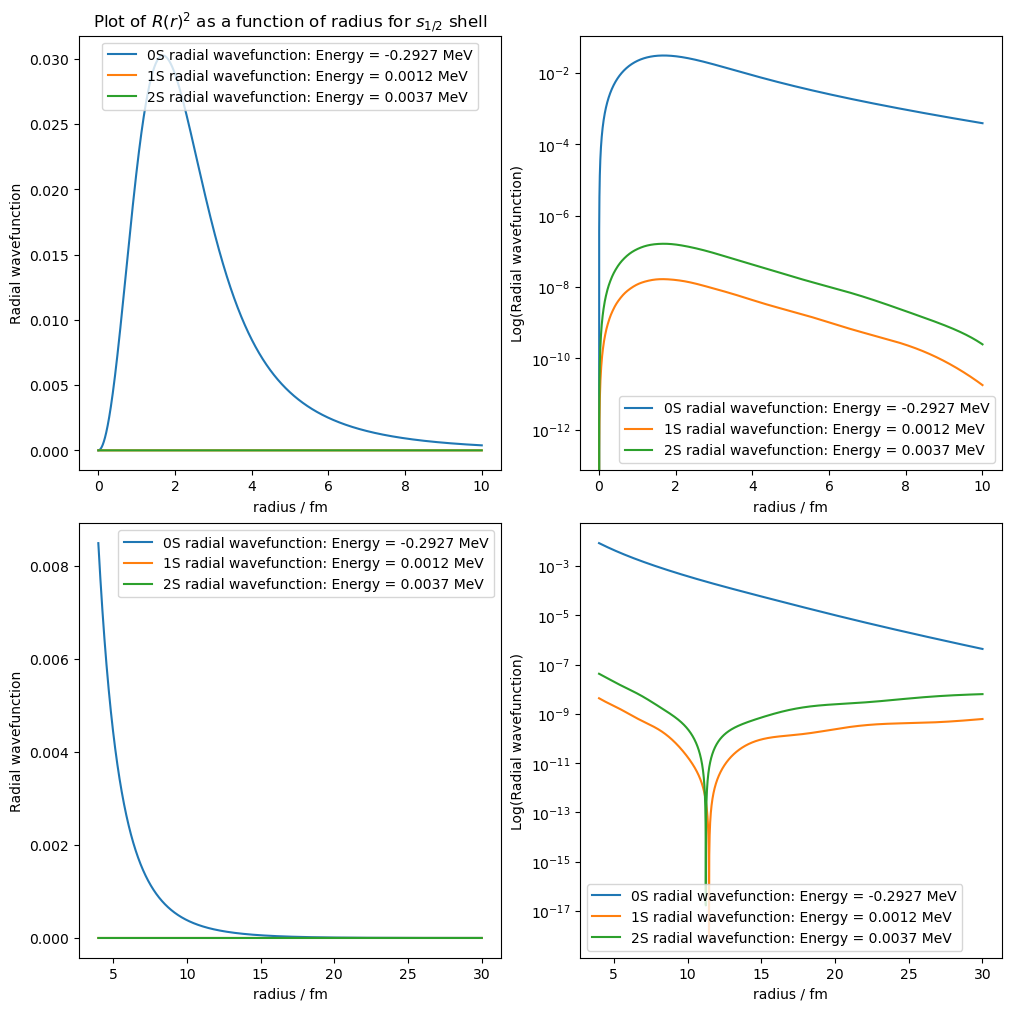

In [20]:
def wavefunction_overlap(i_mixing_coefficients, j_mixing_coefficients, orb_ang_momentum, size=SUM_LIMIT):

    def overlap_mat_elem(i_range_parameter, j_range_parameter, orb_ang_momentum):
        term_1 = (2 / (i_range_parameter * j_range_parameter))**(2.5 + orb_ang_momentum)
        term_2 = (i_range_parameter**(-2) + j_range_parameter**(-2))**(-2.5 - orb_ang_momentum)
        return term_1 * term_2
    overlap_matrix = np.zeros(shape=(size, size))
    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            overlap_matrix[i, j] = overlap_mat_elem(i_range_parameter, j_range_parameter, orb_ang_momentum)
    return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0,0]
print(f'0s wavefunction has overlap {wavefunction_overlap(s0_eigenvector, s0_eigenvector, 0)} with itself')
print(f'1s wavefunction has overlap {wavefunction_overlap(s1_eigenvector, s1_eigenvector, 0)} with itself')
print(f'2s wavefunction has overlap {wavefunction_overlap(s2_eigenvector, s2_eigenvector, 0)} with itself')


def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunction_eigenvector[0, j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(4, 30, 3000)
fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])

ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, s0_eigenvector, 1),
          label=f"0S radial wavefunction: Energy = {s_eigenvalues[0]:.4f} MeV")
ax_1.plot(x_values, radial_wavefunction(x_values, s1_eigenvector, 1),
          label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_1.plot(x_values, radial_wavefunction(x_values, s2_eigenvector, 1),
          label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
ax_1.legend(loc='upper center')

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, np.abs(radial_wavefunction(x_values, s0_eigenvector, 1)),
              label=f"0S radial wavefunction: Energy = {s_eigenvalues[0]:.4f} MeV")
ax_2.semilogy(x_values, np.abs(radial_wavefunction(x_values, s1_eigenvector, 1)),
              label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_2.semilogy(x_values, np.abs(radial_wavefunction(x_values, s2_eigenvector, 1)),
              label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 1),
          label=f"0S radial wavefunction: Energy = {s_eigenvalues[0]:.4f} MeV")
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s1_eigenvector, 1),
          label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s2_eigenvector, 1),
          label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")

ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, np.abs(radial_wavefunction(x_values_2, s0_eigenvector, 1)),
              label=f"0S radial wavefunction: Energy = {s_eigenvalues[0]:.4f} MeV")
ax_4.semilogy(x_values_2, np.abs(radial_wavefunction(x_values_2, s1_eigenvector, 1)),
              label=f"1S radial wavefunction: Energy = {s_eigenvalues[1]:.4f} MeV")
ax_4.semilogy(x_values_2, np.abs(radial_wavefunction(x_values_2, s2_eigenvector, 1)),
              label=f"2S radial wavefunction: Energy = {s_eigenvalues[2]:.4f} MeV")
ax_4.legend()

We want to check the plots we get for orignal potential $(V^{\text{(cn)}})$ and new supersymmetry potetntial  $(V^{\text{(cn)}})-\frac{2\hbar^{2}}{2\mu}\frac{d^{2}}{dr^{2}}(\ln W^{(1)})$ and compare with Baye to check correct form is gotten.

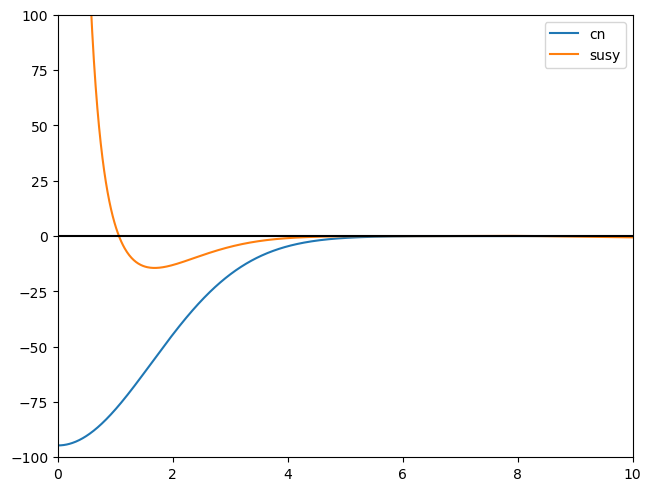

In [23]:
def core_neutron_potential(radius, strength, param):
    return strength * np.exp(-param * radius**2)

def SUSY_potential_func(radius, mixing_coeffs, paramaters):
    potential = 0
    for i in range(len(paramaters)):
        potential += mixing_coeffs[i] * np.exp(-1 * paramaters[i] * radius**2)
    return potential + 197**2 / (REDUCED_MASS * radius**2)

r_vals = np.linspace(0, 10, 1000)
r_vals_2 = np.linspace(0.1, 10, 1000)

cn_potential = core_neutron_potential(r_vals, CENTRAL_POTENTIAL_STRENGTH, CENTRAL_POTENTIAL_PARAMETERS[0])
susy_potential = SUSY_potential_func(r_vals_2, SUSY_POTENTIAL_COEFFS, SUSY_POTENTIAL_PARAMS)

fig = plt.figure(layout='constrained')
ax_1 = fig.add_subplot()
ax_1.plot(r_vals, core_neutron_potential(r_vals, CENTRAL_POTENTIAL_STRENGTH, CENTRAL_POTENTIAL_PARAMETERS[0]), label='cn')
ax_1.plot(r_vals_2, core_neutron_potential(r_vals_2, CENTRAL_POTENTIAL_STRENGTH,
                                         CENTRAL_POTENTIAL_PARAMETERS[0]) + SUSY_potential_func(r_vals_2, SUSY_POTENTIAL_COEFFS,
                                                                                                SUSY_POTENTIAL_PARAMS), label='susy')
ax_1.plot(np.linspace(0,10,10), np.zeros(shape=(10,)), c='k')

ax_1.set_xlim(left=0, right=10)
ax_1.set_ylim(bottom=-100, top=100)

plt.legend()










    